In [202]:
# import libraries

In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [204]:
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score
)
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
from sklearn.preprocessing import LabelEncoder

In [205]:
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

In [206]:
#load dataset
train = pd.read_csv("dataset/train.csv")
test = pd.read_csv("dataset/test.csv")
sample = pd.read_csv("dataset/sample_submission.csv")

In [207]:
train

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy
...,...,...,...,...,...,...,...,...,...,...,...
77294,77294,qp0d4n,49,2:0,0.067203,Residential,1,Not Allowed,No,11.501664,Rainy
77295,77295,qp0d4q,49,2:0,0.022859,Residential,3,Allowed,Yes,14.715254,Foggy
77296,77296,qp0d4w,49,2:0,0.141342,Residential,3,Allowed,Yes,19.678860,Sunny
77297,77297,qp0dhw,49,2:0,0.087574,Residential,1,Not Allowed,No,22.573958,Sunny


In [208]:
test

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,49,2:15,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,NaN,Rainy
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy
...,...,...,...,...,...,...,...,...,...,...
41773,41773,qp0d4q,49,13:45,Street,1,Not Allowed,Yes,19.588991,Sunny
41774,41774,qp0d4w,49,13:45,Residential,2,Not Allowed,Yes,10.735538,Rainy
41775,41775,qp0dhq,49,13:45,Residential,2,Not Allowed,Yes,13.223750,Rainy
41776,41776,qp0dhw,49,13:45,Residential,2,Not Allowed,Yes,12.510917,Rainy


In [209]:
sample

,Index,demand
0,0,0.090768
1,1,0.089885
2,2,0.007037
3,3,0.079087
4,4,0.054636


In [210]:
train.shape

(77299, 11)

In [211]:
test.shape

(41778, 10)

In [212]:
# View Data

train.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [213]:
# Dataset Info

train.info()

<class 'pandas.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  str    
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  str    
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  str    
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  str    
 8   Landmarks      77299 non-null  str    
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  str    
dtypes: float64(2), int64(3), str(6)
memory usage: 9.3 MB


In [214]:
# Missing Values

train.isnull().sum()

Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

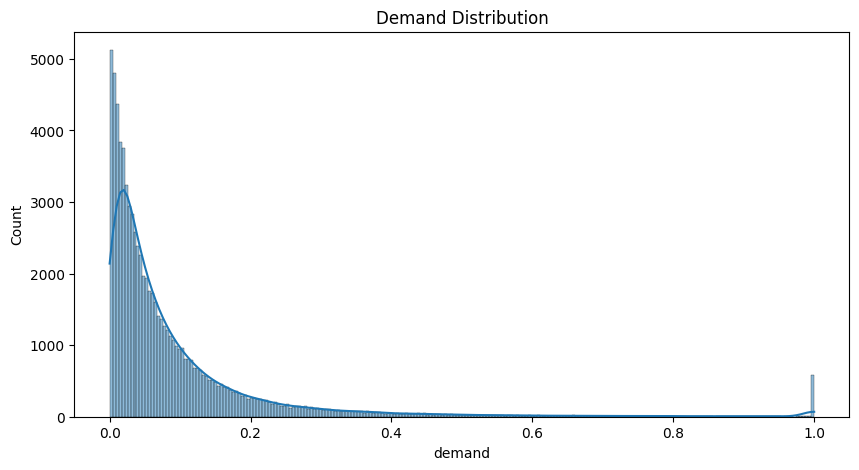

In [215]:
# Target Distribution

plt.figure(figsize=(10,5))

sns.histplot(train["demand"], kde=True)

plt.title("Demand Distribution")

plt.show()

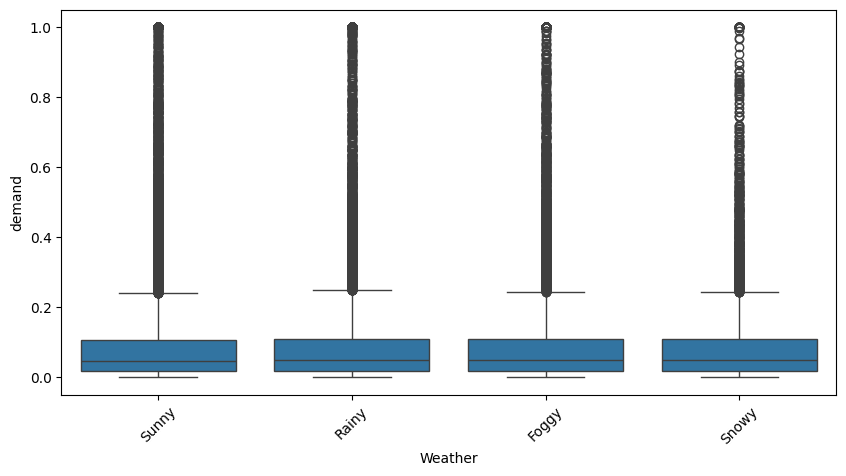

In [216]:
# Weather vs Demand

plt.figure(figsize=(10,5))

sns.boxplot(
    x=train["Weather"],
    y=train["demand"]
)

plt.xticks(rotation=45)

plt.show()

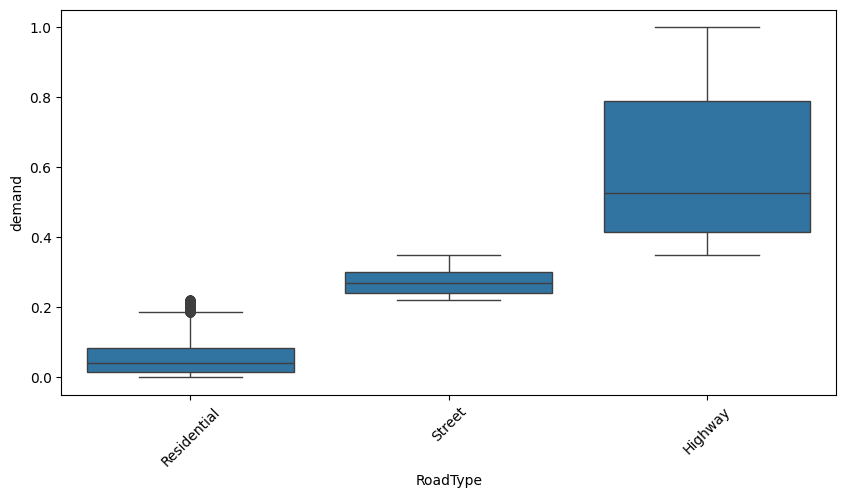

In [217]:
# RoadType vs Demand

plt.figure(figsize=(10,5))

sns.boxplot(
    x=train["RoadType"],
    y=train["demand"]
)

plt.xticks(rotation=45)

plt.show()

In [218]:
# Fill Missing Values
categorical_cols = [
    "geohash",
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "Weather"
]

for col in categorical_cols:

    train[col] = train[col].fillna("Unknown")

    test[col] = test[col].fillna("Unknown")

train["Temperature"] = train["Temperature"].fillna(
    train["Temperature"].median()
)

test["Temperature"] = test["Temperature"].fillna(
    test["Temperature"].median()
)

In [219]:
# Check Missing Values

train.isnull().sum()

Index            0
geohash          0
day              0
timestamp        0
demand           0
RoadType         0
NumberofLanes    0
LargeVehicles    0
Landmarks        0
Temperature      0
Weather          0
dtype: int64

In [220]:
def create_features(df):

    df["hour"] = df["timestamp"].apply(
        lambda x: int(x.split(":")[0])
    )

    df["minute"] = df["timestamp"].apply(
        lambda x: int(x.split(":")[1])
    )

    df["is_weekend"] = df["day"].apply(
        lambda x: 1 if x % 7 in [5,6] else 0
    )

    df["rush_hour"] = df["hour"].apply(
        lambda x: 1 if (7 <= x <= 10) or (17 <= x <= 20) else 0
    )

    df["night"] = df["hour"].apply(
        lambda x: 1 if (x >= 22 or x <= 5) else 0
    )

    def bucket(h):

        if 5 <= h < 10:
            return "Morning"

        elif 10 <= h < 16:
            return "Afternoon"

        elif 16 <= h < 21:
            return "Evening"

        else:
            return "Night"

    df["time_bucket"] = df["hour"].apply(bucket)

    df["lane_temp"] = (
        df["NumberofLanes"] *
        df["Temperature"]
    )

    df["temp_hour"] = (
        df["Temperature"] *
        df["hour"]
    )

    df["hour_sin"] = np.sin(
        2 * np.pi * df["hour"] / 24
    )

    df["hour_cos"] = np.cos(
        2 * np.pi * df["hour"] / 24
    )

    df["temp_x_hour"] = (
        df["Temperature"] *
        df["hour"]
    )

    df["lanes_x_hour"] = (
        df["NumberofLanes"] *
        df["hour"]
    )

    df["rush_temp"] = (
        df["rush_hour"] *
        df["Temperature"]
    )

    return df

In [221]:
# Create Features

train = create_features(train)

test = create_features(test)

In [222]:
# Target Encoding

target_cols = [
    "RoadType",
    "Weather",
    "Landmarks",
    "LargeVehicles"
]

for col in target_cols:

    mean_map = train.groupby(col)["demand"].mean()

    train[col + "_target"] = train[col].map(mean_map)

    test[col + "_target"] = test[col].map(mean_map)

    test[col + "_target"] = test[col + "_target"].fillna(
        train["demand"].mean()
    )

In [223]:
# View Features

train.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,...,temp_hour,hour_sin,hour_cos,temp_x_hour,lanes_x_hour,rush_temp,RoadType_target,Weather_target,Landmarks_target,LargeVehicles_target
0,0,qp02z1,48,0:0,0.048804,Unknown,1,Not Allowed,No,16.382587,...,0.0,0.0,1.0,0.0,0,0.0,0.098263,0.097218,0.096295,0.073986
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,...,0.0,0.0,1.0,0.0,0,0.0,0.057209,0.094247,0.092801,0.131923
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,...,0.0,0.0,1.0,0.0,0,0.0,0.057209,0.094247,0.096295,0.073986
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,16.382587,...,0.0,0.0,1.0,0.0,0,0.0,0.057209,0.094471,0.096295,0.073986
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,...,0.0,0.0,1.0,0.0,0,0.0,0.057209,0.094471,0.096295,0.073986


In [224]:
test.head()

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,...,temp_hour,hour_sin,hour_cos,temp_x_hour,lanes_x_hour,rush_temp,RoadType_target,Weather_target,Landmarks_target,LargeVehicles_target
0,0,qp02z1,49,2:15,Unknown,1,Not Allowed,No,16.471232,Unknown,...,32.942464,0.5,0.866025,32.942464,2,0.0,0.098263,0.097218,0.096295,0.073986
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy,...,12.952427,0.5,0.866025,12.952427,2,0.0,0.057209,0.092581,0.096295,0.073986
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny,...,44.636405,0.5,0.866025,44.636405,6,0.0,0.057209,0.094247,0.092801,0.131923
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,16.471232,Rainy,...,32.942464,0.5,0.866025,32.942464,4,0.0,0.057209,0.094471,0.092801,0.073986
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy,...,36.532324,0.5,0.866025,36.532324,2,0.0,0.057209,0.093372,0.096295,0.073986


In [225]:
# Geohash Encoding
geo_mean = train.groupby("geohash")["demand"].mean()

train["geo_demand_mean"] = train["geohash"].map(geo_mean)

test["geo_demand_mean"] = test["geohash"].map(geo_mean)

test["geo_demand_mean"] = test["geo_demand_mean"].fillna(
    train["demand"].mean()
)



In [226]:
# Geohash Frequency Encoding

geo_freq = train["geohash"].value_counts()

train["geo_freq"] = train["geohash"].map(geo_freq)

test["geo_freq"] = test["geohash"].map(geo_freq)

test["geo_freq"] = test["geo_freq"].fillna(0)

In [227]:
geo_mean

geohash
qp02yc    0.018498
qp02yf    0.029433
qp02yy    0.002902
qp02yz    0.036564
qp02z1    0.040048
            ...   
qp0dn4    0.007811
qp0dn5    0.003714
qp0dnh    0.001401
qp0dnj    0.026414
qp0dnn    0.004244
Name: demand, Length: 1249, dtype: float64

In [228]:
# Merge Data

all_data = pd.concat([
    train.drop(columns=["demand"]),
    test
])

In [229]:
all_data

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,...,hour_cos,temp_x_hour,lanes_x_hour,rush_temp,RoadType_target,Weather_target,Landmarks_target,LargeVehicles_target,geo_demand_mean,geo_freq
0,0,qp02z1,48,0:0,Unknown,1,Not Allowed,No,16.382587,Unknown,...,1.000000,0.000000,0,0.0,0.098263,0.097218,0.096295,0.073986,0.040048,33.0
1,1,qp02zt,48,0:0,Residential,3,Allowed,Yes,31.104565,Sunny,...,1.000000,0.000000,0,0.0,0.057209,0.094247,0.092801,0.131923,0.208766,89.0
2,2,qp08bj,48,0:0,Residential,1,Not Allowed,No,25.919267,Sunny,...,1.000000,0.000000,0,0.0,0.057209,0.094247,0.096295,0.073986,0.127931,67.0
3,3,qp08gt,48,0:0,Residential,1,Not Allowed,No,16.382587,Rainy,...,1.000000,0.000000,0,0.0,0.057209,0.094471,0.096295,0.073986,0.014381,42.0
4,4,qp02zq,48,0:0,Residential,1,Not Allowed,No,10.803667,Rainy,...,1.000000,0.000000,0,0.0,0.057209,0.094471,0.096295,0.073986,0.029300,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41773,41773,qp0d4q,49,13:45,Street,1,Not Allowed,Yes,19.588991,Sunny,...,-0.965926,254.656882,13,0.0,0.273164,0.094247,0.092801,0.073986,0.139208,74.0
41774,41774,qp0d4w,49,13:45,Residential,2,Not Allowed,Yes,10.735538,Rainy,...,-0.965926,139.561989,26,0.0,0.057209,0.094471,0.092801,0.073986,0.113220,101.0
41775,41775,qp0dhq,49,13:45,Residential,2,Not Allowed,Yes,13.223750,Rainy,...,-0.965926,171.908747,26,0.0,0.057209,0.094471,0.092801,0.073986,0.018066,50.0
41776,41776,qp0dhw,49,13:45,Residential,2,Not Allowed,Yes,12.510917,Rainy,...,-0.965926,162.641918,26,0.0,0.057209,0.094471,0.092801,0.073986,0.075075,88.0


In [230]:
# Label Encoding

label_cols = [
    "geohash",
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "Weather",
    "time_bucket"
]

for col in label_cols:

    le = LabelEncoder()

    all_data[col] = le.fit_transform(
        all_data[col].astype(str)
    )

In [231]:
all_data

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,...,hour_cos,temp_x_hour,lanes_x_hour,rush_temp,RoadType_target,Weather_target,Landmarks_target,LargeVehicles_target,geo_demand_mean,geo_freq
0,0,4,48,0:0,3,1,1,0,16.382587,4,...,1.000000,0.000000,0,0.0,0.098263,0.097218,0.096295,0.073986,0.040048,33.0
1,1,25,48,0:0,1,3,0,1,31.104565,3,...,1.000000,0.000000,0,0.0,0.057209,0.094247,0.092801,0.131923,0.208766,89.0
2,2,370,48,0:0,1,1,1,0,25.919267,3,...,1.000000,0.000000,0,0.0,0.057209,0.094247,0.096295,0.073986,0.127931,67.0
3,3,418,48,0:0,1,1,1,0,16.382587,1,...,1.000000,0.000000,0,0.0,0.057209,0.094471,0.096295,0.073986,0.014381,42.0
4,4,22,48,0:0,1,1,1,0,10.803667,1,...,1.000000,0.000000,0,0.0,0.057209,0.094471,0.096295,0.073986,0.029300,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41773,41773,1170,49,13:45,2,1,1,1,19.588991,3,...,-0.965926,254.656882,13,0.0,0.273164,0.094247,0.092801,0.073986,0.139208,74.0
41774,41774,1175,49,13:45,1,2,1,1,10.735538,1,...,-0.965926,139.561989,26,0.0,0.057209,0.094471,0.092801,0.073986,0.113220,101.0
41775,41775,1218,49,13:45,1,2,1,1,13.223750,1,...,-0.965926,171.908747,26,0.0,0.057209,0.094471,0.092801,0.073986,0.018066,50.0
41776,41776,1223,49,13:45,1,2,1,1,12.510917,1,...,-0.965926,162.641918,26,0.0,0.057209,0.094471,0.092801,0.073986,0.075075,88.0


In [232]:
# Split Data

train_encoded = all_data.iloc[:len(train)]

test_encoded = all_data.iloc[len(train):]

In [233]:
train_encoded

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,...,hour_cos,temp_x_hour,lanes_x_hour,rush_temp,RoadType_target,Weather_target,Landmarks_target,LargeVehicles_target,geo_demand_mean,geo_freq
0,0,4,48,0:0,3,1,1,0,16.382587,4,...,1.000000,0.000000,0,0.0,0.098263,0.097218,0.096295,0.073986,0.040048,33.0
1,1,25,48,0:0,1,3,0,1,31.104565,3,...,1.000000,0.000000,0,0.0,0.057209,0.094247,0.092801,0.131923,0.208766,89.0
2,2,370,48,0:0,1,1,1,0,25.919267,3,...,1.000000,0.000000,0,0.0,0.057209,0.094247,0.096295,0.073986,0.127931,67.0
3,3,418,48,0:0,1,1,1,0,16.382587,1,...,1.000000,0.000000,0,0.0,0.057209,0.094471,0.096295,0.073986,0.014381,42.0
4,4,22,48,0:0,1,1,1,0,10.803667,1,...,1.000000,0.000000,0,0.0,0.057209,0.094471,0.096295,0.073986,0.029300,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77294,77294,1169,49,2:0,1,1,1,0,11.501664,1,...,0.866025,23.003328,2,0.0,0.057209,0.094471,0.096295,0.073986,0.026510,68.0
77295,77295,1170,49,2:0,1,3,0,1,14.715254,0,...,0.866025,29.430507,6,0.0,0.057209,0.093372,0.092801,0.131923,0.139208,74.0
77296,77296,1175,49,2:0,1,3,0,1,19.678860,3,...,0.866025,39.357720,6,0.0,0.057209,0.094247,0.092801,0.131923,0.113220,101.0
77297,77297,1223,49,2:0,1,1,1,0,22.573958,3,...,0.866025,45.147916,2,0.0,0.057209,0.094247,0.096295,0.073986,0.075075,88.0


In [234]:
test_encoded

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,...,hour_cos,temp_x_hour,lanes_x_hour,rush_temp,RoadType_target,Weather_target,Landmarks_target,LargeVehicles_target,geo_demand_mean,geo_freq
0,0,4,49,2:15,3,1,1,0,16.471232,4,...,0.866025,32.942464,2,0.0,0.098263,0.097218,0.096295,0.073986,0.040048,33.0
1,1,10,49,2:15,1,1,1,0,6.476213,2,...,0.866025,12.952427,2,0.0,0.057209,0.092581,0.096295,0.073986,0.031742,35.0
2,2,1,49,2:15,1,3,0,1,22.318203,3,...,0.866025,44.636405,6,0.0,0.057209,0.094247,0.092801,0.131923,0.029433,1.0
3,3,8,49,2:15,1,2,1,1,16.471232,1,...,0.866025,32.942464,4,0.0,0.057209,0.094471,0.092801,0.073986,0.039944,39.0
4,4,12,49,2:15,1,1,1,0,18.266162,0,...,0.866025,36.532324,2,0.0,0.057209,0.093372,0.096295,0.073986,0.054593,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41773,41773,1170,49,13:45,2,1,1,1,19.588991,3,...,-0.965926,254.656882,13,0.0,0.273164,0.094247,0.092801,0.073986,0.139208,74.0
41774,41774,1175,49,13:45,1,2,1,1,10.735538,1,...,-0.965926,139.561989,26,0.0,0.057209,0.094471,0.092801,0.073986,0.113220,101.0
41775,41775,1218,49,13:45,1,2,1,1,13.223750,1,...,-0.965926,171.908747,26,0.0,0.057209,0.094471,0.092801,0.073986,0.018066,50.0
41776,41776,1223,49,13:45,1,2,1,1,12.510917,1,...,-0.965926,162.641918,26,0.0,0.057209,0.094471,0.092801,0.073986,0.075075,88.0


In [235]:
# Drop Original Columns

drop_cols = [
    "RoadType",
    "Weather",
    "Landmarks",
    "LargeVehicles"
]

train = train.drop(columns=drop_cols)

test = test.drop(columns=drop_cols)

In [236]:
# Create X and y

X = train_encoded.drop(columns=[
    "Index",
    "timestamp"
])

y = train["demand"]

X_test = test_encoded.drop(columns=[
    "Index",
    "timestamp"
])

In [237]:
X

,geohash,day,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,...,hour_cos,temp_x_hour,lanes_x_hour,rush_temp,RoadType_target,Weather_target,Landmarks_target,LargeVehicles_target,geo_demand_mean,geo_freq
0,4,48,3,1,1,0,16.382587,4,0,0,...,1.000000,0.000000,0,0.0,0.098263,0.097218,0.096295,0.073986,0.040048,33.0
1,25,48,1,3,0,1,31.104565,3,0,0,...,1.000000,0.000000,0,0.0,0.057209,0.094247,0.092801,0.131923,0.208766,89.0
2,370,48,1,1,1,0,25.919267,3,0,0,...,1.000000,0.000000,0,0.0,0.057209,0.094247,0.096295,0.073986,0.127931,67.0
3,418,48,1,1,1,0,16.382587,1,0,0,...,1.000000,0.000000,0,0.0,0.057209,0.094471,0.096295,0.073986,0.014381,42.0
4,22,48,1,1,1,0,10.803667,1,0,0,...,1.000000,0.000000,0,0.0,0.057209,0.094471,0.096295,0.073986,0.029300,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77294,1169,49,1,1,1,0,11.501664,1,2,0,...,0.866025,23.003328,2,0.0,0.057209,0.094471,0.096295,0.073986,0.026510,68.0
77295,1170,49,1,3,0,1,14.715254,0,2,0,...,0.866025,29.430507,6,0.0,0.057209,0.093372,0.092801,0.131923,0.139208,74.0
77296,1175,49,1,3,0,1,19.678860,3,2,0,...,0.866025,39.357720,6,0.0,0.057209,0.094247,0.092801,0.131923,0.113220,101.0
77297,1223,49,1,1,1,0,22.573958,3,2,0,...,0.866025,45.147916,2,0.0,0.057209,0.094247,0.096295,0.073986,0.075075,88.0


In [238]:
X_test

,geohash,day,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,...,hour_cos,temp_x_hour,lanes_x_hour,rush_temp,RoadType_target,Weather_target,Landmarks_target,LargeVehicles_target,geo_demand_mean,geo_freq
0,4,49,3,1,1,0,16.471232,4,2,15,...,0.866025,32.942464,2,0.0,0.098263,0.097218,0.096295,0.073986,0.040048,33.0
1,10,49,1,1,1,0,6.476213,2,2,15,...,0.866025,12.952427,2,0.0,0.057209,0.092581,0.096295,0.073986,0.031742,35.0
2,1,49,1,3,0,1,22.318203,3,2,15,...,0.866025,44.636405,6,0.0,0.057209,0.094247,0.092801,0.131923,0.029433,1.0
3,8,49,1,2,1,1,16.471232,1,2,15,...,0.866025,32.942464,4,0.0,0.057209,0.094471,0.092801,0.073986,0.039944,39.0
4,12,49,1,1,1,0,18.266162,0,2,15,...,0.866025,36.532324,2,0.0,0.057209,0.093372,0.096295,0.073986,0.054593,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41773,1170,49,2,1,1,1,19.588991,3,13,45,...,-0.965926,254.656882,13,0.0,0.273164,0.094247,0.092801,0.073986,0.139208,74.0
41774,1175,49,1,2,1,1,10.735538,1,13,45,...,-0.965926,139.561989,26,0.0,0.057209,0.094471,0.092801,0.073986,0.113220,101.0
41775,1218,49,1,2,1,1,13.223750,1,13,45,...,-0.965926,171.908747,26,0.0,0.057209,0.094471,0.092801,0.073986,0.018066,50.0
41776,1223,49,1,2,1,1,12.510917,1,13,45,...,-0.965926,162.641918,26,0.0,0.057209,0.094471,0.092801,0.073986,0.075075,88.0


In [239]:
# Feature Shape

X.shape

(77299, 27)

In [240]:
# Train Validation Split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=42
)

In [241]:
cat_model = CatBoostRegressor(

    iterations=3000,

    learning_rate=0.03,

    depth=8,

    loss_function='RMSE',

    eval_metric='R2',

    random_seed=42,

    verbose=200
)

In [242]:
cat_model.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=200
)

0:	learn: 0.0514500	test: 0.0518817	best: 0.0518817 (0)	total: 8.31ms	remaining: 24.9s
200:	learn: 0.9343497	test: 0.9310623	best: 0.9310623 (200)	total: 1.58s	remaining: 22s
400:	learn: 0.9447564	test: 0.9390522	best: 0.9390522 (400)	total: 3.14s	remaining: 20.4s
600:	learn: 0.9511485	test: 0.9434295	best: 0.9434295 (600)	total: 4.67s	remaining: 18.6s
800:	learn: 0.9551038	test: 0.9459464	best: 0.9459464 (800)	total: 6.2s	remaining: 17s
1000:	learn: 0.9579875	test: 0.9476469	best: 0.9476475 (999)	total: 7.72s	remaining: 15.4s
1200:	learn: 0.9602689	test: 0.9488227	best: 0.9488227 (1200)	total: 9.32s	remaining: 14s
1400:	learn: 0.9622217	test: 0.9498317	best: 0.9498317 (1400)	total: 10.9s	remaining: 12.5s
1600:	learn: 0.9637928	test: 0.9504775	best: 0.9504775 (1600)	total: 12.5s	remaining: 10.9s
1800:	learn: 0.9651418	test: 0.9510112	best: 0.9510112 (1800)	total: 14.1s	remaining: 9.37s
2000:	learn: 0.9662944	test: 0.9513441	best: 0.9513441 (2000)	total: 15.7s	remaining: 7.83s
2200:	lea

CatBoostRegressor(depth=8, eval_metric='R2', iterations=3000, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=200)

In [243]:
# CatBoost Score

cat_pred = cat_model.predict(X_valid)

cat_r2 = r2_score(
    y_valid,
    cat_pred
)

cat_r2

0.952652559517828

In [244]:
lgb_model = LGBMRegressor(

    n_estimators=3000,

    learning_rate=0.03,

    max_depth=10,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42
)

In [245]:
# Train LightGBM

lgb_model.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003610 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2075
[LightGBM] [Info] Number of data points in the train set: 61839, number of used features: 27
[LightGBM] [Info] Start training from score 0.093784


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,10
,learning_rate,0.03
,n_estimators,3000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [246]:
# LightGBM Score

lgb_pred = lgb_model.predict(X_valid)

lgb_r2 = r2_score(
    y_valid,
    lgb_pred
)

lgb_r2

0.9521320107788942

In [247]:
xgb_model = XGBRegressor(

    n_estimators=3000,

    learning_rate=0.03,

    max_depth=10,

    subsample=0.8,

    colsample_bytree=0.8,

    objective='reg:squarederror',

    random_state=42
)

In [248]:
# Train XGBoost

xgb_model.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [249]:
# XGBoost Score

xgb_pred = xgb_model.predict(X_valid)

xgb_r2 = r2_score(
    y_valid,
    xgb_pred
)

xgb_r2

0.9469676202729012

In [250]:
ensemble_pred = (

    0.50 * cat_pred +

    0.30 * lgb_pred +

    0.20 * xgb_pred
)

In [251]:
# Official Hackathon Score

from sklearn import metrics

score = max(
    0,
    100 * metrics.r2_score(
        y_valid,
        ensemble_pred
    )
)

print("Hackathon Score :", score)

Hackathon Score : 95.38337312381586


In [252]:
# Official Hackathon Score

from sklearn import metrics

score = max(
    0,
    100 * metrics.r2_score(
        y_valid,
        ensemble_pred
    )
)

print("Hackathon Score :", score)

Hackathon Score : 95.38337312381586


In [253]:
# Error Metrics

mae = mean_absolute_error(
    y_valid,
    ensemble_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        ensemble_pred
    )
)

print("MAE :", mae)

print("RMSE :", rmse)

MAE : 0.02026837510283991
RMSE : 0.030563874075689012


In [254]:
# Feature Importance

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": cat_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

In [255]:
# Top Features

importance.head(20)

,Feature,Importance
25,geo_demand_mean,35.509188
21,RoadType_target,19.011586
2,RoadType,11.706489
0,geohash,7.069446
16,hour_sin,5.414760
8,hour,4.488233
17,hour_cos,4.073118
26,geo_freq,3.280651
13,time_bucket,1.504518
19,lanes_x_hour,1.299612


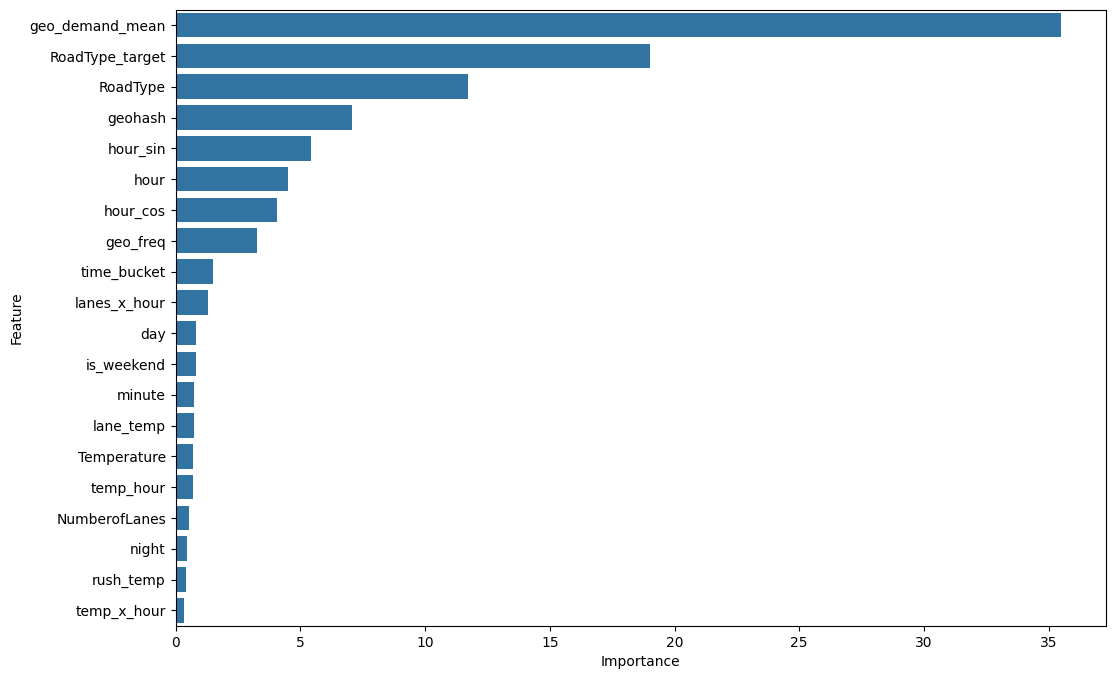

In [256]:
# Importance Plot

plt.figure(figsize=(12,8))

sns.barplot(
    x=importance.head(20)["Importance"],
    y=importance.head(20)["Feature"]
)

plt.show()

In [257]:
# KFold Setup

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [258]:
# Cross Validation

kfold_scores = cross_val_score(

    cat_model,

    X,

    y,

    scoring='r2',

    cv=kf
)

0:	learn: 0.0514500	total: 12.4ms	remaining: 37.1s
200:	learn: 0.9345149	total: 1.53s	remaining: 21.3s
400:	learn: 0.9451471	total: 3.04s	remaining: 19.7s
600:	learn: 0.9513127	total: 4.59s	remaining: 18.3s
800:	learn: 0.9553291	total: 6.31s	remaining: 17.3s
1000:	learn: 0.9581761	total: 7.93s	remaining: 15.8s
1200:	learn: 0.9605554	total: 9.61s	remaining: 14.4s
1400:	learn: 0.9624009	total: 11.4s	remaining: 13.1s
1600:	learn: 0.9638895	total: 13.2s	remaining: 11.6s
1800:	learn: 0.9651826	total: 14.8s	remaining: 9.83s
2000:	learn: 0.9664156	total: 16.3s	remaining: 8.14s
2200:	learn: 0.9674535	total: 17.8s	remaining: 6.48s
2400:	learn: 0.9684227	total: 19.4s	remaining: 4.84s
2600:	learn: 0.9693286	total: 20.9s	remaining: 3.21s
2800:	learn: 0.9701532	total: 22.5s	remaining: 1.6s
2999:	learn: 0.9708782	total: 24s	remaining: 0us
0:	learn: 0.0513929	total: 7.65ms	remaining: 22.9s
200:	learn: 0.9335103	total: 1.52s	remaining: 21.2s
400:	learn: 0.9447551	total: 3.06s	remaining: 19.8s
600:	lea

In [259]:
# KFold Scores

kfold_scores

array([0.95269111, 0.9504738 , 0.95262692, 0.94801381, 0.95329078])

In [260]:
# Mean Score

kfold_scores.mean()

0.9514192852013712

In [261]:
# Train Full Data

cat_model.fit(X, y)

lgb_model.fit(X, y)

xgb_model.fit(X, y)

0:	learn: 0.0514932	total: 9ms	remaining: 27s
200:	learn: 0.9343825	total: 1.75s	remaining: 24.4s
400:	learn: 0.9448211	total: 3.5s	remaining: 22.7s
600:	learn: 0.9510931	total: 5.32s	remaining: 21.3s
800:	learn: 0.9552247	total: 7.12s	remaining: 19.5s
1000:	learn: 0.9581388	total: 8.91s	remaining: 17.8s
1200:	learn: 0.9603629	total: 10.7s	remaining: 16s
1400:	learn: 0.9620881	total: 12.5s	remaining: 14.3s
1600:	learn: 0.9635979	total: 14.3s	remaining: 12.5s
1800:	learn: 0.9648550	total: 16.1s	remaining: 10.7s
2000:	learn: 0.9659736	total: 17.8s	remaining: 8.91s
2200:	learn: 0.9670036	total: 19.6s	remaining: 7.12s
2400:	learn: 0.9679140	total: 21.4s	remaining: 5.33s
2600:	learn: 0.9687499	total: 23.2s	remaining: 3.55s
2800:	learn: 0.9695052	total: 24.9s	remaining: 1.77s
2999:	learn: 0.9701900	total: 26.8s	remaining: 0us
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002508 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [262]:
# Test Predictions

cat_test_pred = cat_model.predict(X_test)

lgb_test_pred = lgb_model.predict(X_test)

xgb_test_pred = xgb_model.predict(X_test)

In [263]:
# Final Ensemble

final_predictions = (

    0.45 * cat_test_pred +

    0.35 * lgb_test_pred +

    0.20 * xgb_test_pred
)

In [264]:
final_predictions.shape

(41778,)

In [265]:
# Create Submission

submission = pd.DataFrame({

    "Index": test["Index"],

    "demand": final_predictions
})

In [266]:
# View Submission

submission.head()

,Index,demand
0,0,0.061251
1,1,0.022570
2,2,0.034382
3,3,0.041029
4,4,0.045059


In [267]:
# Save Submission

submission.to_csv(
    "submission.csv",
    index=False
)

In [268]:
# Verify Submission

check = pd.read_csv("submission.csv")

check.head()

,Index,demand
0,0,0.061251
1,1,0.022570
2,2,0.034382
3,3,0.041029
4,4,0.045059


In [269]:
# Submission Shape

check.shape

(41778, 2)

In [270]:
test.shape

(41778, 25)